In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import linregress

In [2]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav_history = pd.read_csv("../data/raw/02_nav_history.csv")

performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [3]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [4]:
nav_history.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [5]:
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [6]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [7]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

In [ ]:
nav_history.info()


<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [9]:
nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

In [10]:
nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)

In [11]:
nav_history.head(20)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [12]:
nav_history["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

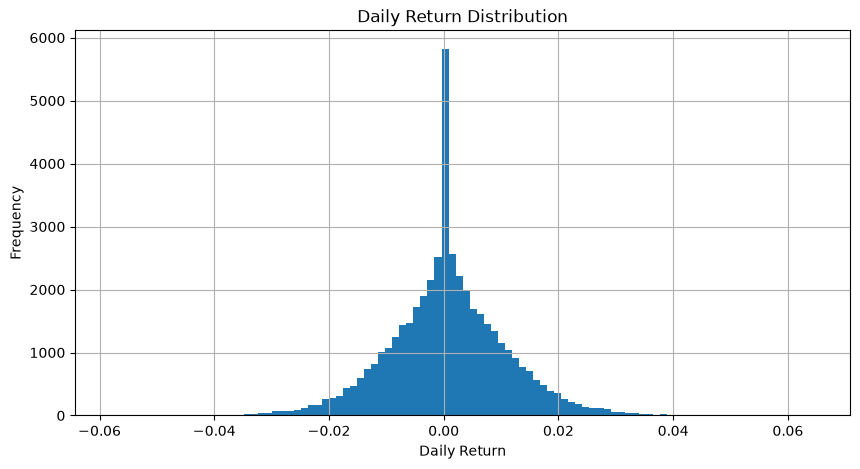

In [13]:
plt.figure(figsize=(10,5))

nav_history["daily_return"].hist(bins=100)

plt.title("Daily Return Distribution")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.show()

In [14]:
nav_history.to_csv(
    "../reports/daily_returns.csv",
    index=False
)

In [15]:
nav_history["amfi_code"].nunique()

40

In [16]:
nav_history.groupby("amfi_code").size().head()

amfi_code
100016    1150
100025    1150
100033    1150
101206    1150
101207    1150
dtype: int64

In [17]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [18]:
import pandas as pd
import numpy as np

from scipy.stats import linregress

In [19]:
nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

nav_history.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [20]:
def calculate_cagr(group, years):

    required_days = years * 252

    if len(group) < required_days:
        return np.nan

    start_nav = group.iloc[-required_days]["nav"]
    end_nav = group.iloc[-1]["nav"]

    cagr = (end_nav / start_nav) ** (1 / years) - 1

    return cagr

In [21]:
cagr_table = pd.DataFrame()

cagr_table["amfi_code"] = (
    nav_history["amfi_code"]
    .unique()
)

cagr_table["CAGR_1Y"] = (
    nav_history
    .groupby("amfi_code")
    .apply(lambda x: calculate_cagr(x, 1))
    .values
)

cagr_table["CAGR_3Y"] = (
    nav_history
    .groupby("amfi_code")
    .apply(lambda x: calculate_cagr(x, 3))
    .values
)

cagr_table["CAGR_5Y"] = (
    nav_history
    .groupby("amfi_code")
    .apply(lambda x: calculate_cagr(x, 5))
    .values
)

cagr_table.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-0.033055,-0.000316,NaN
1,100025,0.025018,0.046143,NaN
2,100033,0.477346,0.336292,NaN
3,101206,0.450939,0.325286,NaN
4,101207,-0.242421,-0.026965,NaN


In [22]:
cagr_table.to_csv(
    "../reports/cagr_summary.csv",
    index=False
)

print("CAGR file saved.")

CAGR file saved.


In [23]:
daily_stats = (
    nav_history
    .groupby("amfi_code")["daily_return"]
    .agg(["mean", "std"])
    .reset_index()
)

daily_stats.head()

,amfi_code,mean,std
0,100016,0.000142,0.009164
1,100025,0.000170,0.002460
2,100033,0.001080,0.011929
3,101206,0.000852,0.009177
4,101207,0.000424,0.016251


In [24]:
risk_free_rate = 0.065 / 252

daily_stats["Sharpe"] = (
    (daily_stats["mean"] - risk_free_rate)
    / daily_stats["std"]
) * np.sqrt(252)

daily_stats.head()

,amfi_code,mean,std,Sharpe
0,100016,0.000142,0.009164,-0.201517
1,100025,0.000170,0.002460,-0.567095
2,100033,0.001080,0.011929,1.093699
3,101206,0.000852,0.009177,1.027213
4,101207,0.000424,0.016251,0.162661


In [25]:
daily_stats = daily_stats.sort_values(
    "Sharpe",
    ascending=False
)

daily_stats.head(10)

,amfi_code,mean,std,Sharpe
34,148567,0.001074,0.008941,1.448291
30,120843,0.001082,0.010008,1.306744
36,148569,0.001124,0.011134,1.234930
19,119551,0.000917,0.008656,1.208267
25,120505,0.001161,0.012152,1.180101
38,149323,0.001055,0.011179,1.132122
2,100033,0.001080,0.011929,1.093699
9,118632,0.000865,0.008913,1.081659
3,101206,0.000852,0.009177,1.027213
24,120504,0.000843,0.009048,1.026524


In [26]:
daily_stats.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio saved.")

Sharpe Ratio saved.


In [27]:
def sortino(group):

    downside = group[group < 0]

    if len(downside) == 0:
        return np.nan

    downside_std = downside.std()

    return (
        (group.mean() - risk_free_rate)
        / downside_std
    ) * np.sqrt(252)

In [28]:
sortino_table = (
    nav_history
    .groupby("amfi_code")["daily_return"]
    .apply(sortino)
    .reset_index()
)

sortino_table.columns = [
    "amfi_code",
    "Sortino"
]

sortino_table.head()

,amfi_code,Sortino
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [29]:
sortino_table.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

print("Sortino saved.")

Sortino saved.


In [30]:
# Select only NIFTY100 benchmark

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [31]:
nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

nifty100 = nifty100.sort_values("date")

nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [32]:
nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [33]:
merged = pd.merge(

    nav_history,

    nifty100[[
        "date",
        "benchmark_return"
    ]],

    on="date",

    how="inner"

)

merged.head()

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,-0.013540
2,100016,2022-01-05,521.7239,0.012865,0.004003
3,100016,2022-01-06,515.7880,-0.011377,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,0.006150


In [34]:
def calculate_alpha_beta(group):

    data = group.dropna(
        subset=[
            "daily_return",
            "benchmark_return"
        ]
    )

    if len(data) < 30:
        return pd.Series({
            "Alpha": np.nan,
            "Beta": np.nan
        })

    result = linregress(

        data["benchmark_return"],

        data["daily_return"]

    )

    alpha = result.intercept * 252

    beta = result.slope

    return pd.Series({

        "Alpha": alpha,

        "Beta": beta

    })

In [35]:
alpha_beta = (

    merged

    .groupby("amfi_code")

    .apply(calculate_alpha_beta)

    .reset_index()

)

alpha_beta.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [36]:
alpha_beta.to_csv(

    "../reports/alpha_beta.csv",

    index=False

)

print("Alpha Beta saved.")

Alpha Beta saved.


In [37]:
def calculate_drawdown(group):

    group = group.sort_values("date")

    running_max = group["nav"].cummax()

    drawdown = (

        group["nav"]

        / running_max

    ) - 1

    return pd.Series({

        "Max_Drawdown": drawdown.min()

    })

In [38]:
drawdown_table = (

    nav_history

    .groupby("amfi_code")

    .apply(calculate_drawdown)

    .reset_index()

)

drawdown_table.head()

,amfi_code,Max_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [39]:
drawdown_table.to_csv(

    "../reports/drawdown_summary.csv",

    index=False

)

print("Drawdown saved.")

Drawdown saved.


In [40]:
scorecard = cagr_table.merge(
    daily_stats[["amfi_code", "Sharpe"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    alpha_beta,
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    drawdown_table,
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    performance[["amfi_code", "expense_ratio_pct"]],
    on="amfi_code",
    how="left"
)

scorecard.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe,Alpha,Beta,Max_Drawdown,expense_ratio_pct
0,100016,-0.033055,-0.000316,NaN,-0.201517,0.037476,-0.058268,-0.247344,1.55
1,100025,0.025018,0.046143,NaN,-0.567095,0.042818,0.001158,-0.043083,0.56
2,100033,0.477346,0.336292,NaN,1.093699,0.271954,0.005104,-0.162172,1.38
3,101206,0.450939,0.325286,NaN,1.027213,0.213998,0.021086,-0.112916,1.60
4,101207,-0.242421,-0.026965,NaN,0.162661,0.108971,-0.065289,-0.354469,1.53


In [41]:
scorecard["Return_Rank"] = scorecard["CAGR_3Y"].rank(ascending=False)

scorecard["Sharpe_Rank"] = scorecard["Sharpe"].rank(ascending=False)

scorecard["Alpha_Rank"] = scorecard["Alpha"].rank(ascending=False)

scorecard["Expense_Rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)

scorecard["Drawdown_Rank"] = scorecard["Max_Drawdown"].rank(ascending=False)

scorecard.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe,Alpha,Beta,Max_Drawdown,expense_ratio_pct,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank
0,100016,-0.033055,-0.000316,NaN,-0.201517,0.037476,-0.058268,-0.247344,1.55,36.0,35.0,39.0,32.0,34.0
1,100025,0.025018,0.046143,NaN,-0.567095,0.042818,0.001158,-0.043083,0.56,33.0,39.0,38.0,2.0,4.0
2,100033,0.477346,0.336292,NaN,1.093699,0.271954,0.005104,-0.162172,1.38,2.0,7.0,6.0,17.0,20.0
3,101206,0.450939,0.325286,NaN,1.027213,0.213998,0.021086,-0.112916,1.60,3.0,9.0,12.0,36.5,9.0
4,101207,-0.242421,-0.026965,NaN,0.162661,0.108971,-0.065289,-0.354469,1.53,39.0,28.0,27.0,28.5,38.0


In [42]:
scorecard["Score"] = (

    (41 - scorecard["Return_Rank"]) * 30 +

    (41 - scorecard["Sharpe_Rank"]) * 25 +

    (41 - scorecard["Alpha_Rank"]) * 20 +

    (41 - scorecard["Expense_Rank"]) * 15 +

    (41 - scorecard["Drawdown_Rank"]) * 10

) / 40

scorecard = scorecard.sort_values(
    "Score",
    ascending=False
)

scorecard.head(10)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe,Alpha,Beta,Max_Drawdown,expense_ratio_pct,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Score
34,148567,0.145807,0.312786,NaN,1.448291,0.269838,0.023684,-0.112657,1.46,4.0,1.0,7.0,23.0,8.0,84.7500
2,100033,0.477346,0.336292,NaN,1.093699,0.271954,0.005104,-0.162172,1.38,2.0,7.0,6.0,17.0,20.0,82.2500
25,120505,0.303534,0.302065,NaN,1.180101,0.292636,0.000549,-0.181885,1.36,5.0,5.0,3.0,15.0,25.0,82.2500
30,120843,0.284811,0.256619,NaN,1.306744,0.273305,-0.022830,-0.129740,1.45,10.0,2.0,5.0,22.0,13.0,79.7500
24,120504,0.115007,0.283698,NaN,1.026524,0.211948,0.016232,-0.125883,0.80,6.0,10.0,13.0,12.0,12.0,77.7500
16,119094,0.309182,0.360660,NaN,0.998231,0.260767,-0.066265,-0.209609,1.38,1.0,11.0,9.0,17.0,28.0,77.0000
19,119551,0.488839,0.277274,NaN,1.208267,0.232010,-0.031751,-0.150124,1.54,8.0,4.0,10.0,30.5,17.0,73.3125
3,101206,0.450939,0.325286,NaN,1.027213,0.213998,0.021086,-0.112916,1.60,3.0,9.0,12.0,36.5,9.0,72.6875
21,119598,0.845322,0.278144,NaN,0.945308,0.303370,-0.023196,-0.287060,1.43,7.0,14.0,1.0,21.0,36.0,71.1250
36,148569,0.444657,0.233171,NaN,1.234930,0.282704,0.018134,-0.163967,1.60,13.0,3.0,4.0,36.5,21.0,69.9375


In [43]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard saved.")

Fund Scorecard saved.


In [44]:
top5 = scorecard.head(5)

top5

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe,Alpha,Beta,Max_Drawdown,expense_ratio_pct,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Score
34,148567,0.145807,0.312786,NaN,1.448291,0.269838,0.023684,-0.112657,1.46,4.0,1.0,7.0,23.0,8.0,84.75
2,100033,0.477346,0.336292,NaN,1.093699,0.271954,0.005104,-0.162172,1.38,2.0,7.0,6.0,17.0,20.0,82.25
25,120505,0.303534,0.302065,NaN,1.180101,0.292636,0.000549,-0.181885,1.36,5.0,5.0,3.0,15.0,25.0,82.25
30,120843,0.284811,0.256619,NaN,1.306744,0.273305,-0.022830,-0.129740,1.45,10.0,2.0,5.0,22.0,13.0,79.75
24,120504,0.115007,0.283698,NaN,1.026524,0.211948,0.016232,-0.125883,0.80,6.0,10.0,13.0,12.0,12.0,77.75


In [45]:
top5 = scorecard.head(5)

top5

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe,Alpha,Beta,Max_Drawdown,expense_ratio_pct,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Score
34,148567,0.145807,0.312786,NaN,1.448291,0.269838,0.023684,-0.112657,1.46,4.0,1.0,7.0,23.0,8.0,84.75
2,100033,0.477346,0.336292,NaN,1.093699,0.271954,0.005104,-0.162172,1.38,2.0,7.0,6.0,17.0,20.0,82.25
25,120505,0.303534,0.302065,NaN,1.180101,0.292636,0.000549,-0.181885,1.36,5.0,5.0,3.0,15.0,25.0,82.25
30,120843,0.284811,0.256619,NaN,1.306744,0.273305,-0.022830,-0.129740,1.45,10.0,2.0,5.0,22.0,13.0,79.75
24,120504,0.115007,0.283698,NaN,1.026524,0.211948,0.016232,-0.125883,0.80,6.0,10.0,13.0,12.0,12.0,77.75


In [46]:
top5_codes = top5["amfi_code"].tolist()

top5_codes

[148567, 100033, 120505, 120843, 120504]

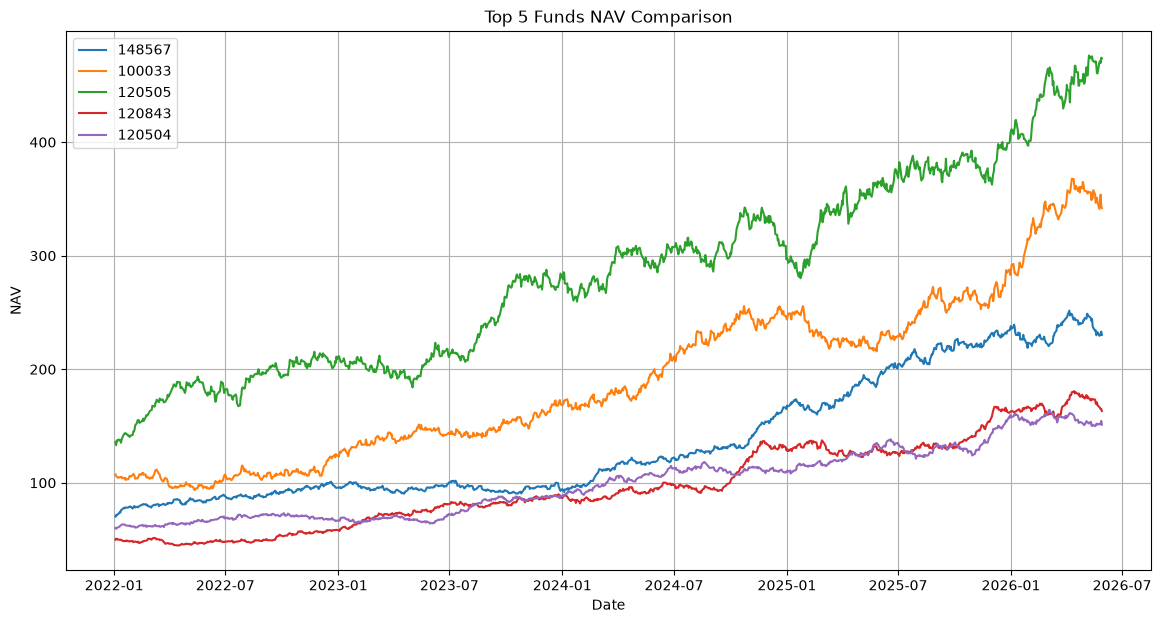

In [47]:
plt.figure(figsize=(14,7))

for code in top5_codes:

    fund = nav_history[
        nav_history["amfi_code"] == code
    ]

    plt.plot(
        fund["date"],
        fund["nav"],
        label=str(code)
    )

plt.title("Top 5 Funds NAV Comparison")

plt.xlabel("Date")

plt.ylabel("NAV")

plt.legend()

plt.grid(True)

plt.show()

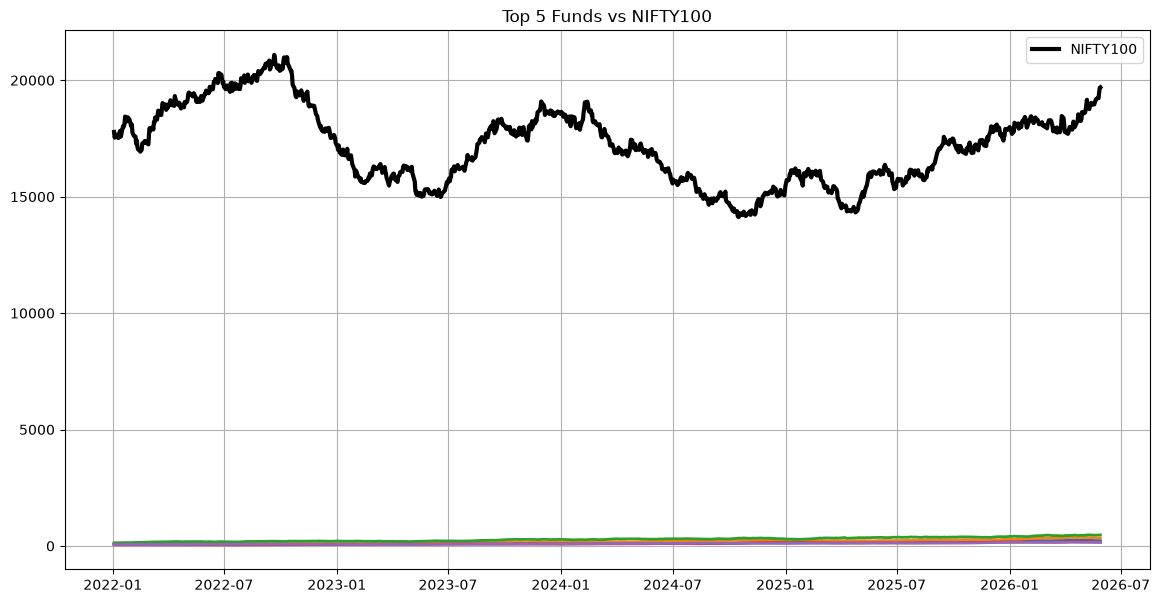

In [48]:
plt.figure(figsize=(14,7))

for code in top5_codes:

    fund = nav_history[
        nav_history["amfi_code"] == code
    ]

    plt.plot(
        fund["date"],
        fund["nav"],
        linewidth=2
    )

plt.plot(
    nifty100["date"],
    nifty100["close_value"],
    color="black",
    linewidth=3,
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY100")

plt.legend()

plt.grid(True)

plt.show()

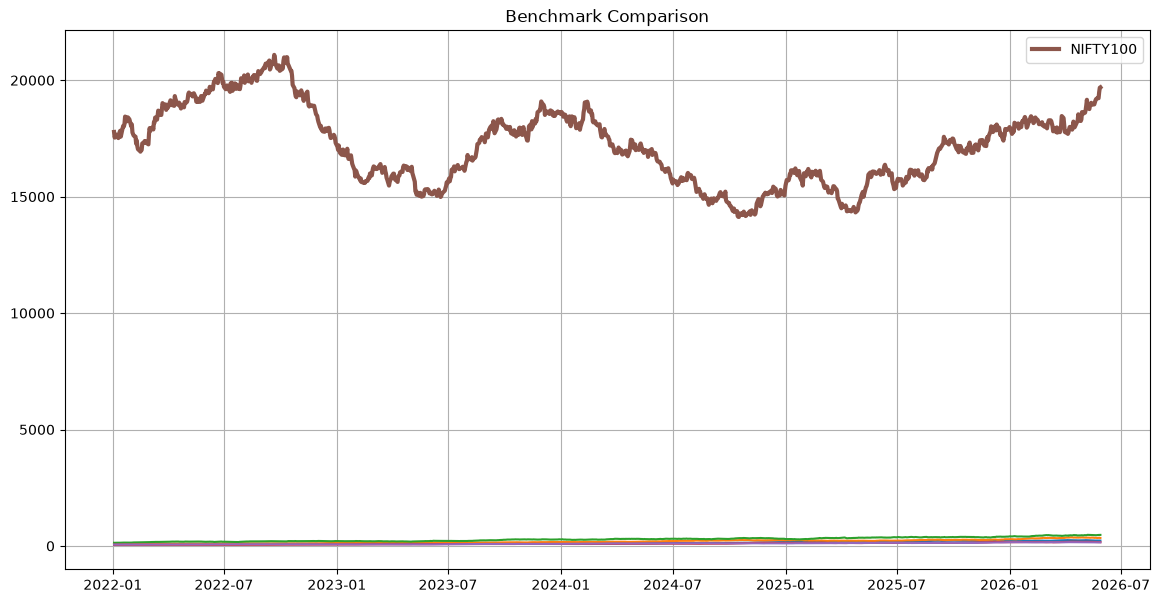

Chart Saved


In [49]:
plt.figure(figsize=(14,7))

for code in top5_codes:

    fund = nav_history[
        nav_history["amfi_code"] == code
    ]

    plt.plot(
        fund["date"],
        fund["nav"]
    )

plt.plot(
    nifty100["date"],
    nifty100["close_value"],
    linewidth=3,
    label="NIFTY100"
)

plt.legend()

plt.title("Benchmark Comparison")

plt.grid(True)

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart Saved")

In [50]:
tracking_error = []

for code in top5_codes:

    temp = merged[
        merged["amfi_code"] == code
    ].dropna()

    te = (
        (temp["daily_return"] - temp["benchmark_return"])
        .std()
    ) * np.sqrt(252)

    tracking_error.append({
        "amfi_code": code,
        "Tracking_Error": te
    })

tracking_error = pd.DataFrame(tracking_error)

tracking_error

,amfi_code,Tracking_Error
0,148567,0.189664
1,100033,0.228699
2,120505,0.231968
3,120843,0.206425
4,120504,0.191587


In [51]:
tracking_error.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

print("Tracking Error saved.")

Tracking Error saved.
